# Mobile Addiction Classification - Exploratory Data Analysis

This notebook contains the data loading and exploratory data analysis components of the mobile addiction classification project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All imports successful")

All imports successful


## 1. Load & Explore Data

In [2]:
# Load data
data = pd.read_csv('../data/raw/mobile_addiction.csv')

# Drop unnamed index column if present
if data.columns[0].startswith('Unnamed'):
    data = data.drop(data.columns[0], axis=1)

print(f"Shape: {data.shape}")
data.head()

Shape: (13589, 11)


,daily_screen_time,app_sessions,social_media_usage,gaming_time,notifications,night_usage,age,work_study_hours,stress_level,apps_installed,addicted
0,2,29,0,0,49,0,44,5,3,35,not addicted
1,6,29,1,2,65,1,29,5,9,21,addicted
2,9,28,2,0,57,3,28,7,5,39,addicted
3,6,39,2,0,69,1,28,6,8,24,addicted
4,5,37,3,1,64,2,27,4,5,26,addicted


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13589 entries, 0 to 13588
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   daily_screen_time   13589 non-null  int64 
 1   app_sessions        13589 non-null  int64 
 2   social_media_usage  13589 non-null  int64 
 3   gaming_time         13589 non-null  int64 
 4   notifications       13589 non-null  int64 
 5   night_usage         13589 non-null  int64 
 6   age                 13589 non-null  int64 
 7   work_study_hours    13589 non-null  int64 
 8   stress_level        13589 non-null  int64 
 9   apps_installed      13589 non-null  int64 
 10  addicted            13589 non-null  object
dtypes: int64(10), object(1)
memory usage: 1.1+ MB


addicted
addicted        6846
not addicted    6743
Name: count, dtype: int64


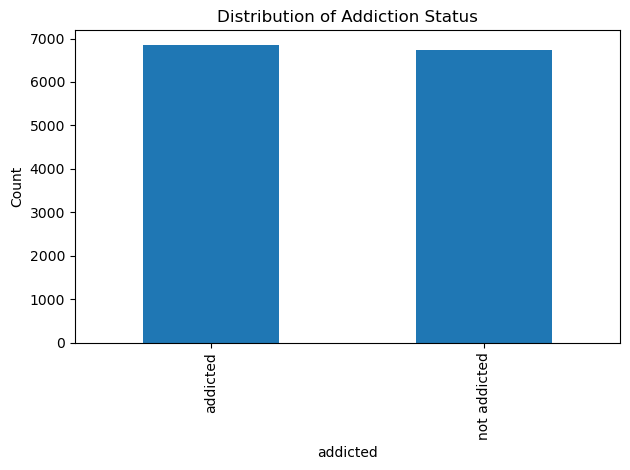

In [4]:
# Target variable distribution
print(data['addicted'].value_counts())
data['addicted'].value_counts().plot(kind='bar', title='Distribution of Addiction Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [5]:
# Statistical summary of numerical features
data.describe().T

,count,mean,std,min,25%,50%,75%,max
daily_screen_time,13589.0,3.768121,1.897280,0.0,2.0,4.0,5.0,12.0
app_sessions,13589.0,30.037604,7.406585,8.0,25.0,30.0,35.0,60.0
social_media_usage,13589.0,1.545956,1.204830,0.0,1.0,1.0,2.0,7.0
gaming_time,13589.0,1.034219,0.993172,0.0,0.0,1.0,2.0,6.0
notifications,13589.0,60.015306,12.732064,25.0,50.0,59.0,70.0,103.0
night_usage,13589.0,0.990213,0.946606,0.0,0.0,1.0,2.0,6.0
age,13589.0,33.055707,10.118145,15.0,25.0,33.0,41.0,55.0
work_study_hours,13589.0,5.978070,2.071390,0.0,5.0,6.0,7.0,14.0
stress_level,13589.0,4.265288,2.288454,0.0,3.0,4.0,6.0,10.0
apps_installed,13589.0,27.532048,5.894790,10.0,23.0,27.0,31.0,55.0


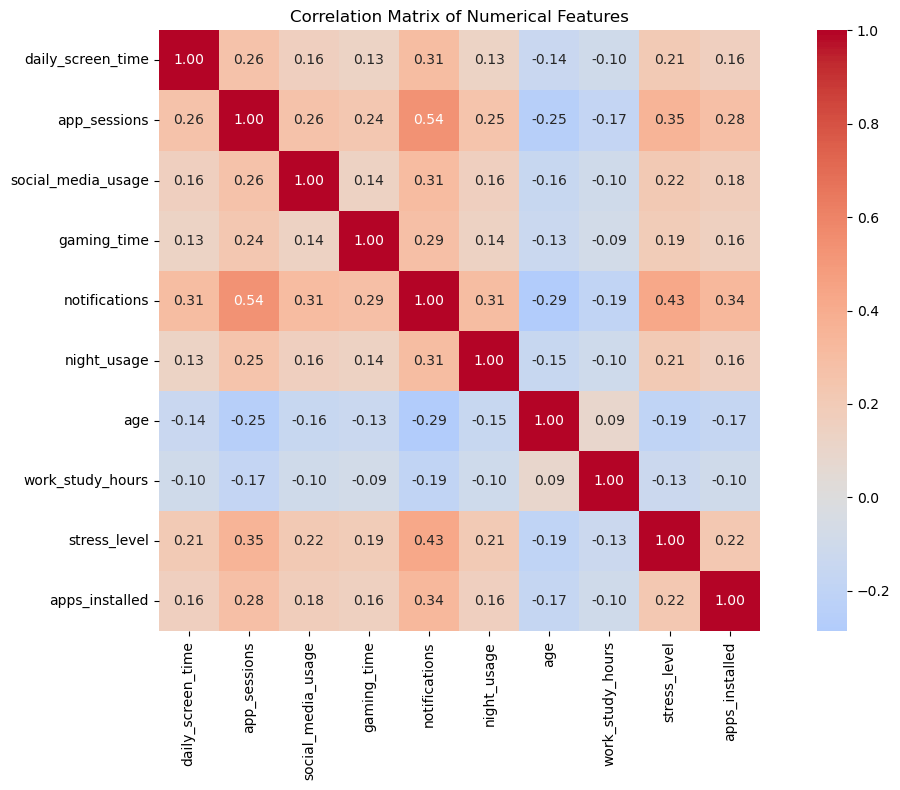

In [6]:
# Correlation analysis
numeric_cols = data.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = data[numeric_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

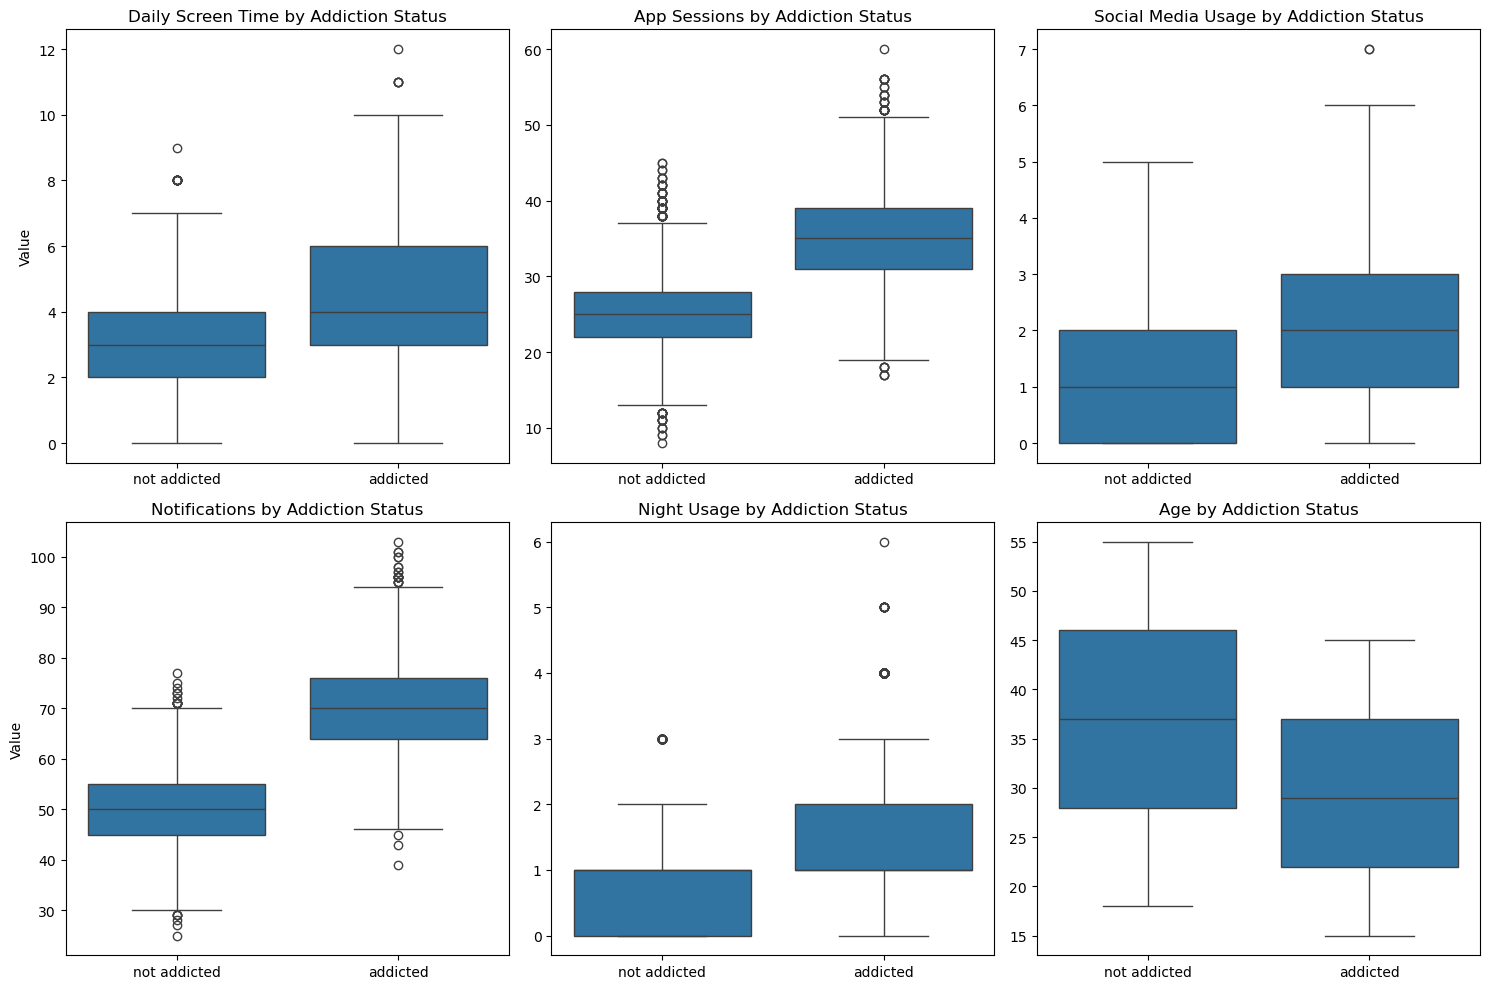

In [7]:
# Distribution of key features by addiction status
key_features = ['daily_screen_time', 'app_sessions', 'social_media_usage', 
                'notifications', 'night_usage', 'age']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, feature in enumerate(key_features):
    if feature in data.columns:
        sns.boxplot(data=data, x='addicted', y=feature, ax=axes[i])
        axes[i].set_title(f'{feature.replace("_", " ").title()} by Addiction Status')
        axes[i].set_xlabel('')
        if i % 3 == 0:
            axes[i].set_ylabel('Value')
        else:
            axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

In [8]:
# Check for missing values
missing_values = data.isnull().sum()
print("Missing values:")
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")

Missing values:
Series([], dtype: int64)
No missing values found in the dataset.


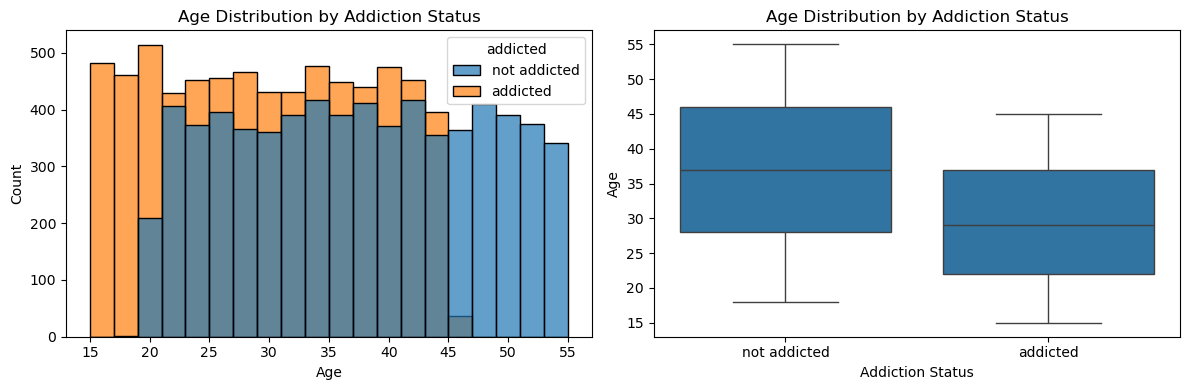

In [9]:
# Age distribution analysis
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(data=data, x='age', hue='addicted', bins=20, alpha=0.7)
plt.title('Age Distribution by Addiction Status')
plt.xlabel('Age')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='addicted', y='age')
plt.title('Age Distribution by Addiction Status')
plt.xlabel('Addiction Status')
plt.ylabel('Age')

plt.tight_layout()
plt.show()

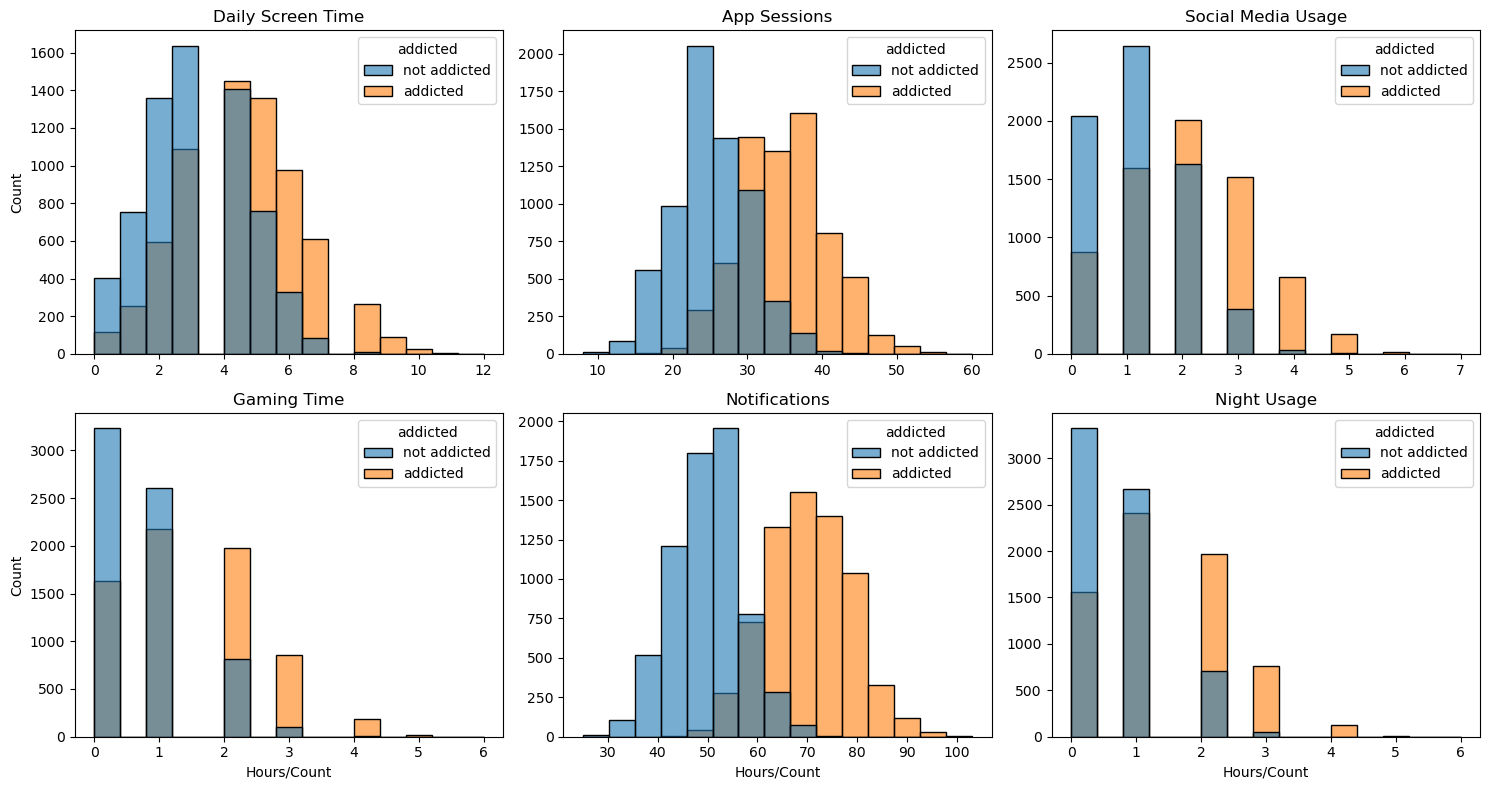

In [10]:
# Usage patterns analysis
usage_features = ['daily_screen_time', 'app_sessions', 'social_media_usage', 
                  'gaming_time', 'notifications', 'night_usage']

# Create usage patterns by addiction status
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for i, feature in enumerate(usage_features):
    if feature in data.columns:
        sns.histplot(data=data, x=feature, hue='addicted', bins=15, 
                    alpha=0.6, ax=axes[i])
        axes[i].set_title(f'{feature.replace("_", " ").title()}')
        if i >= 3:
            axes[i].set_xlabel('Hours/Count')
        else:
            axes[i].set_xlabel('')
        if i % 3 == 0:
            axes[i].set_ylabel('Count')
        else:
            axes[i].set_ylabel('')

plt.tight_layout()
plt.show()

## EDA Summary

Key findings from the exploratory data analysis:

1. **Dataset Balance**: The dataset is well-balanced with approximately equal numbers of addicted and non-addicted users.

2. **No Missing Values**: The dataset contains no missing values, which simplifies preprocessing.

3. **Feature Correlations**: Several features show moderate correlations with addiction status, particularly screen time, notifications, and night usage.

4. **Age Patterns**: There appear to be some age-related patterns in mobile addiction that could be useful for prediction.

5. **Usage Patterns**: Different usage patterns (social media, gaming, notifications) show distinct distributions between addicted and non-addicted users.

The next steps will involve preprocessing the data and building machine learning models to predict mobile addiction based on these features.